In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.formula.api as smf
import math

1. Importing Data Set

In [4]:
Sales=pd.read_csv(r"C:\Users\anany\Downloads\Chocolate Sales (2) (1).csv")

In [5]:
Sales

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


2.DATA CLEANING

In [6]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [7]:
Sales['Date'] = pd.to_datetime(Sales['Date'], dayfirst=True) #To change the dtype from object to datetime

In [8]:
Sales['Amount'] = Sales['Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

In [9]:
Sales['Amount'] = pd.to_numeric(Sales['Amount'])

In [10]:
Sales['Amount'] = Sales['Amount'].astype(int) #To change the dtype from object to integar

In [13]:
Sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   int64         
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 154.0+ KB


In [25]:
Sales.head() #To display first 5 rows

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184


In [26]:
Sales.tail() #To display last 5 rows

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504,397
3281,Karlen McCaffrey,India,70% Dark Bites,2024-05-23,5915,355


In [27]:
Sales.describe() #To describe the data

,Date,Amount,Boxes Shipped
count,3282,3282.000000,3282.000000
mean,2023-05-03 15:09:06.252284928,6030.015539,164.666971
min,2022-01-03 00:00:00,7.000000,1.000000
25%,2022-07-04 00:00:00,2521.250000,71.000000
50%,2023-05-11 00:00:00,5225.500000,137.000000
75%,2024-03-02 00:00:00,8556.250000,232.000000
max,2024-08-31 00:00:00,26170.000000,778.000000
std,NaN,4393.958836,124.024736


In [14]:
Sales.rename(columns={"Product":"Product_Name"},inplace=True) #To rename coloumn name Product

In [15]:
Sales #Final Dataset

,Sales Person,Country,Product_Name,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,2024-05-17,5303,354
3278,Jehu Rudeforth,USA,White Choc,2024-06-07,7339,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,2024-07-26,616,238
3280,Dotty Strutley,India,Eclairs,2024-07-28,2504,397


3.CORRELATION

In [32]:
correlation_matrix = Sales[['Amount', 'Boxes Shipped']].corr()
print(correlation_matrix)

                 Amount  Boxes Shipped
Amount         1.000000      -0.013155
Boxes Shipped -0.013155       1.000000


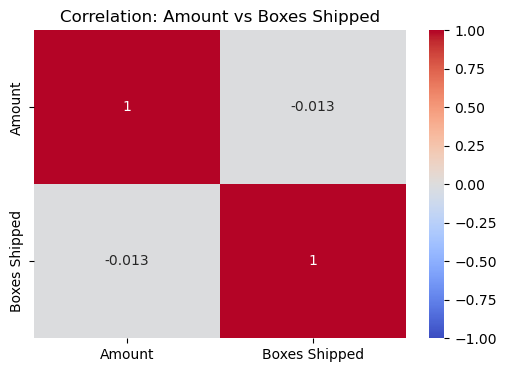

In [33]:
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Amount vs Boxes Shipped')
plt.show() #Visual representation of correlation

4.LINEAR REGRESSION

In [43]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression

In [45]:
X = Sales[['Boxes Shipped']]
y = Sales['Amount']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [52]:
y_pred = model.predict(X_test)

In [53]:
print(f"Intercept: {model.intercept_}")
print(f"Slope (Coefficient): {model.coef_[0]}")

Intercept: 6144.568336869417
Slope (Coefficient): -0.403877912052983


NameError: name 'correlation' is not defined

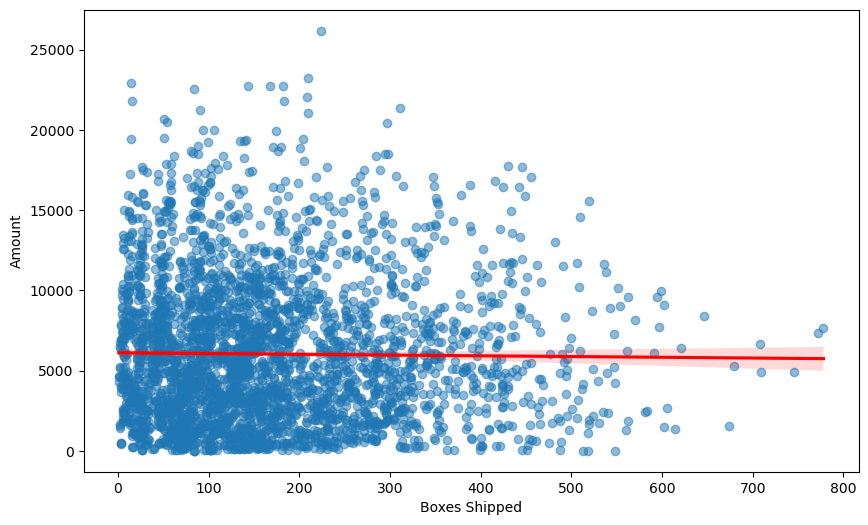

In [55]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Boxes Shipped', y='Amount', data=Sales, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Sales Regression (Correlation: {correlation:.2f})')
plt.show() #Visual representation of regression and correlation

5.DESCRIPTIVE STATISTICS

In [57]:
print("--- Descriptive Statistics ---")
stats_summary = Sales.describe().transpose()
stats_summary['mode'] = Sales.select_dtypes(include=[np.number]).mode().iloc[0]
print(stats_summary)

--- Descriptive Statistics ---
                count                           mean                  min  \
Date             3282  2023-05-03 15:09:06.252284928  2022-01-03 00:00:00   
Amount         3282.0                    6030.015539                  7.0   
Boxes Shipped  3282.0                     164.666971                  1.0   

                               25%                  50%                  75%  \
Date           2022-07-04 00:00:00  2023-05-11 00:00:00  2024-03-02 00:00:00   
Amount                     2521.25               5225.5              8556.25   
Boxes Shipped                 71.0                137.0                232.0   

                               max          std    mode  
Date           2024-08-31 00:00:00          NaN     NaN  
Amount                     26170.0  4393.958836  2303.0  
Boxes Shipped                778.0   124.024736    24.0  


6. DISTRIBUTION OF PRICE PER BOX

In [58]:
Sales['Price_Per_Box'] = Sales['Amount'] / Sales['Boxes Shipped'] # Added new coloumn price per box

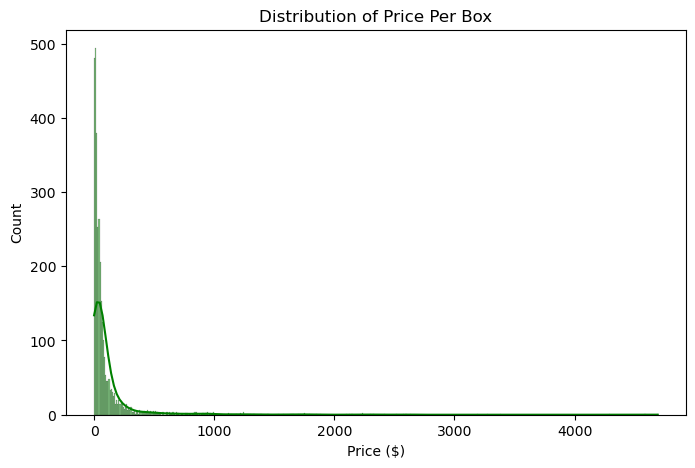

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(Sales['Price_Per_Box'], kde=True, color='green')
plt.title('Distribution of Price Per Box')
plt.xlabel('Price ($)')
plt.show()

7.TREND ANALYSIS

In [62]:
Sales_time = Sales.set_index('Date')
monthly_sales = Sales_time.resample('M')['Amount'].sum()

C:\Users\anany\AppData\Local\Temp\ipykernel_17344\2162674893.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = Sales_time.resample('M')['Amount'].sum()


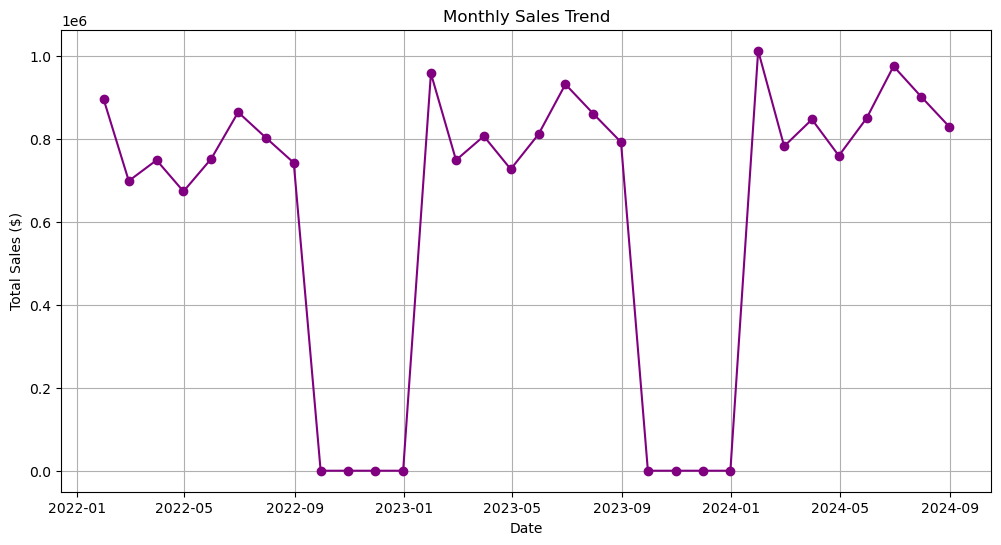

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='purple')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True)
plt.show()

8.DATA VISUALIZATION

Count Plot (Categorical Frequency)

C:\Users\anany\AppData\Local\Temp\ipykernel_17344\2008283587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = Sales, x = 'Product_Name', palette = 'dark')


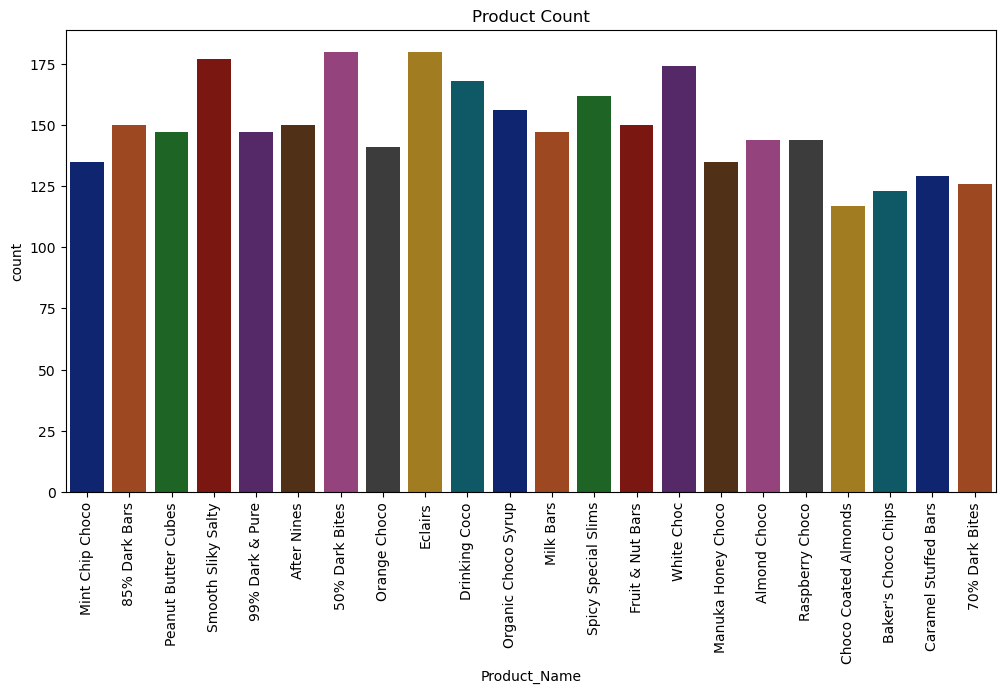

In [72]:
plt.figure(figsize=(12, 6))
sns.countplot(data = Sales, x = 'Product_Name', palette = 'dark')
plt.xticks(rotation=90)
plt.title('Product Count')
plt.show() # To show sales of every product

C:\Users\anany\AppData\Local\Temp\ipykernel_17344\2601046182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Country', data=Sales, order=country_order, palette='pastel')


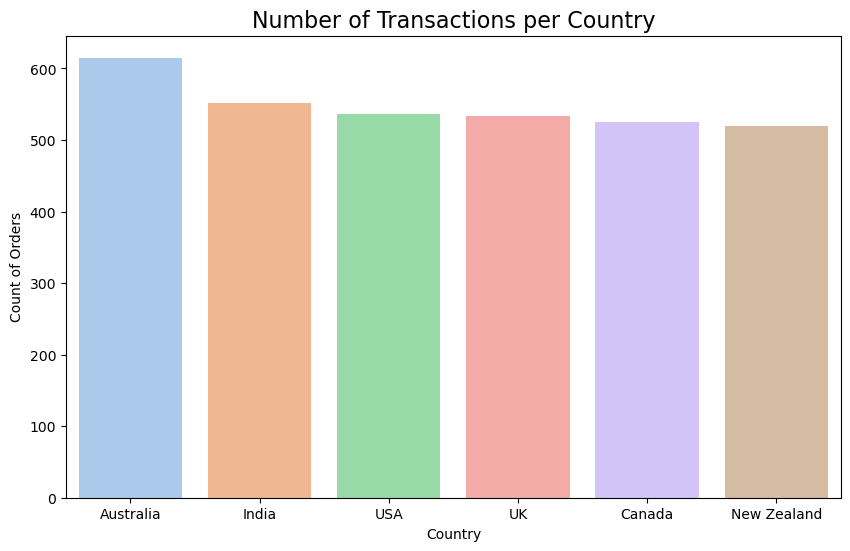

In [131]:
plt.figure(figsize=(10, 6))
country_order = Sales['Country'].value_counts().index
sns.countplot(x='Country', data=Sales, order=country_order, palette='pastel')
plt.title('Number of Transactions per Country', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Count of Orders')
plt.show() # To show sales for every country

C:\Users\anany\AppData\Local\Temp\ipykernel_17344\3388462311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = Sales, x = 'Sales Person', palette = 'deep')


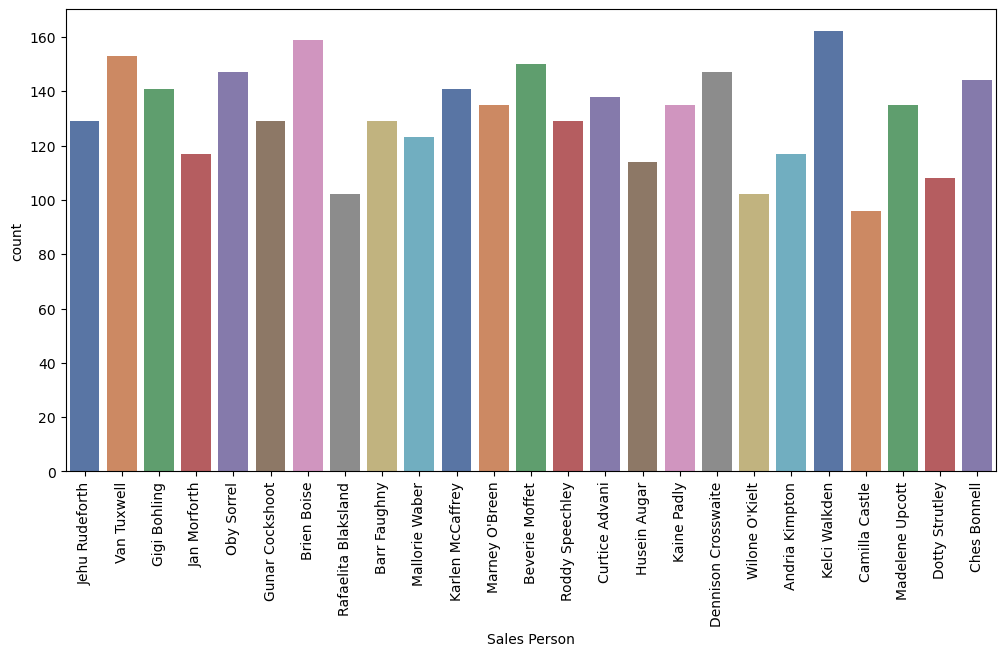

In [78]:
plt.figure(figsize=(12, 6))
sns.countplot(data = Sales, x = 'Sales Person', palette = 'deep')
plt.xticks(rotation=90)
plt.show() # To show sales for every sales person

Bar Graph

C:\Users\anany\AppData\Local\Temp\ipykernel_17344\3988406581.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Amount', y='Product_Name', data=product_sales, palette='viridis')


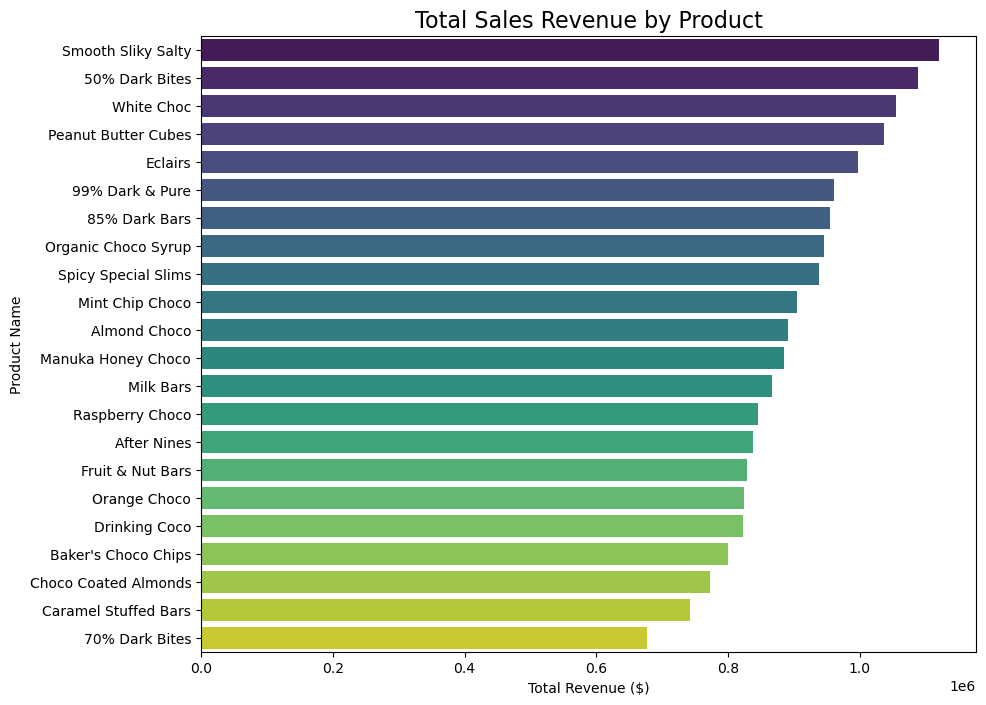

In [75]:
product_sales = Sales.groupby('Product_Name')['Amount'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(x='Amount', y='Product_Name', data=product_sales, palette='viridis')
plt.title('Total Sales Revenue by Product', fontsize=16)
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Name')
plt.show() # To show total sales by revenue

Line Chart (Time Series)

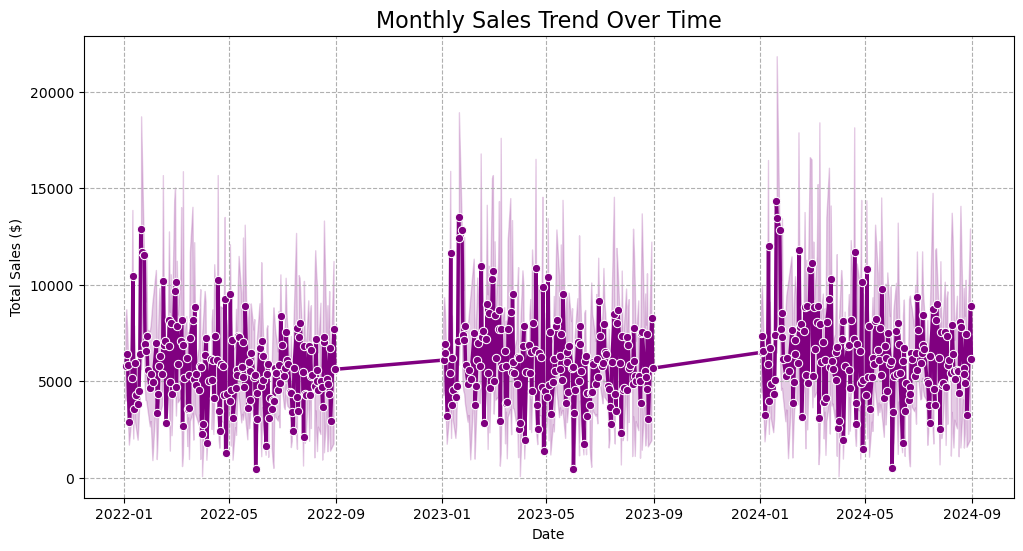

In [126]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Amount', data=Sales, marker='o', color='purple', linewidth=2.5)

plt.title('Monthly Sales Trend Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle='--')
plt.show() # To show monthly sales trend over years

Histplot

<Axes: xlabel='Amount', ylabel='Count'>

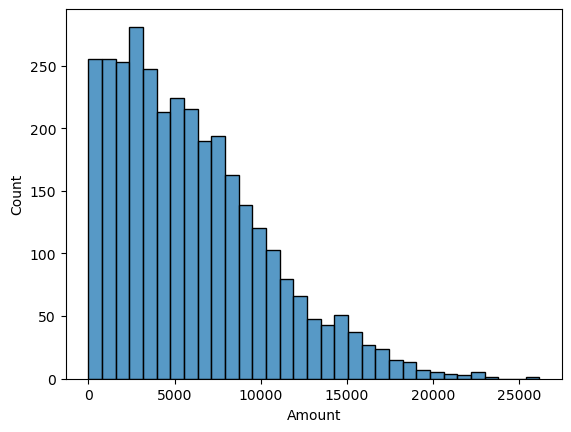

In [80]:
sns.histplot(Sales['Amount'])
plt.show() # To show amount of sales on histogram

 Histogram (Distribution Plot)

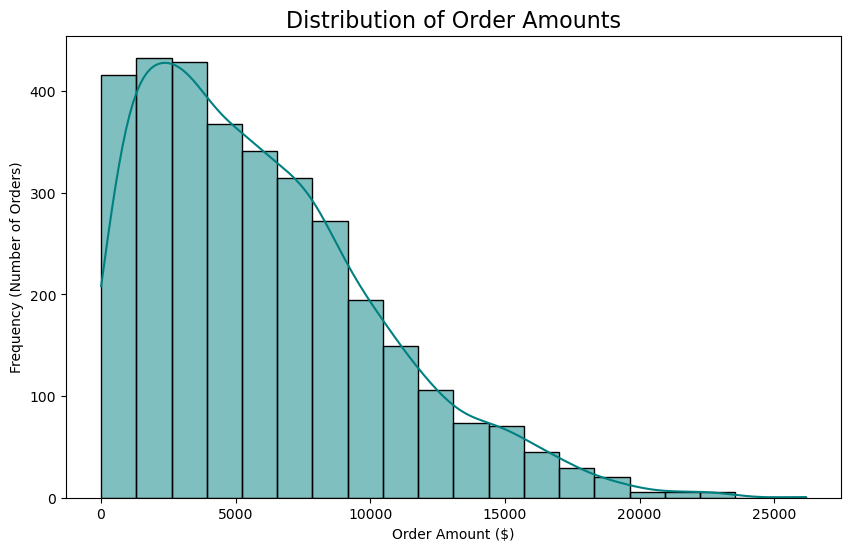

In [129]:
plt.figure(figsize=(10, 6))

sns.histplot(Sales['Amount'], bins=20, kde=True, color='teal')

plt.title('Distribution of Order Amounts', fontsize=16)
plt.xlabel('Order Amount ($)')
plt.ylabel('Frequency (Number of Orders)')
plt.show() # To visually represent histogram on distribution plot

Scatter Plot with Regression Line

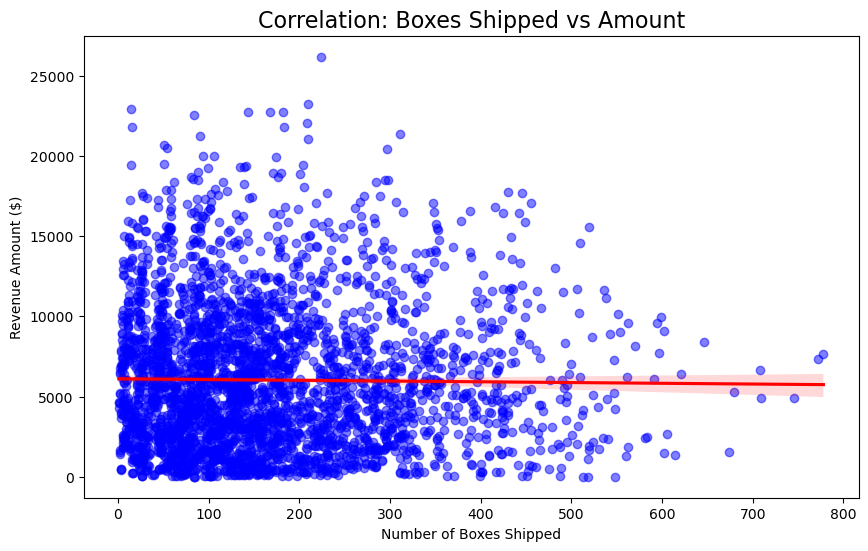

In [128]:
plt.figure(figsize=(10, 6))

sns.regplot(x='Boxes Shipped', y='Amount', data=Sales, 
            scatter_kws={'alpha':0.5, 'color':'blue'}, 
            line_kws={'color':'red'})

plt.title('Correlation: Boxes Shipped vs Amount', fontsize=16)
plt.xlabel('Number of Boxes Shipped')
plt.ylabel('Revenue Amount ($)')
plt.show() # To visually represent scatter graph

 Heatmap (Correlation Matrix)

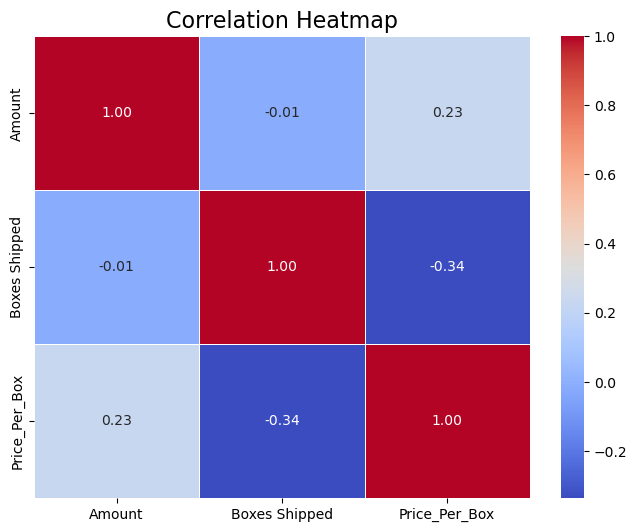

In [130]:
numeric_cols = Sales.select_dtypes(include=['int64', 'float64', 'int32'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Correlation Heatmap', fontsize=16)
plt.show() # To show correlation heatmap 

Boxplot

<Axes: ylabel='Sales Person'>

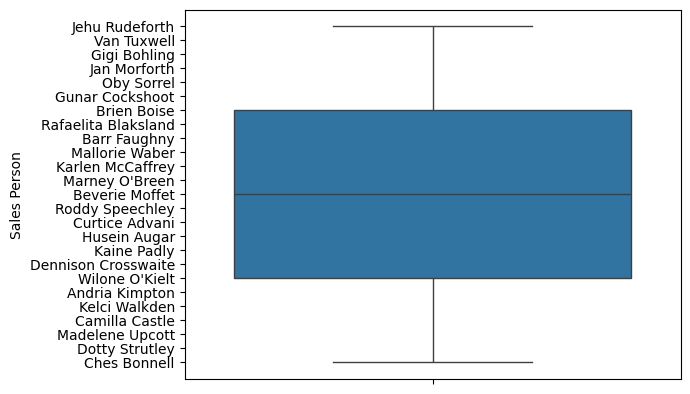

In [81]:
sns.boxplot(Sales['Sales Person'])
plt.show() # to represent boxplot 

Correlation Matrix

In [142]:
corr_matrix = (hm.corr())
print(corr_matrix) # To show correlation matrix

                   Date    Amount  Boxes Shipped  Price_Per_Box
Date           1.000000  0.053080       0.002236       0.023994
Amount         0.053080  1.000000      -0.013155       0.231117
Boxes Shipped  0.002236 -0.013155       1.000000      -0.336025
Price_Per_Box  0.023994  0.231117      -0.336025       1.000000


Text(0.5, 1.0, 'Correlation Matrix')

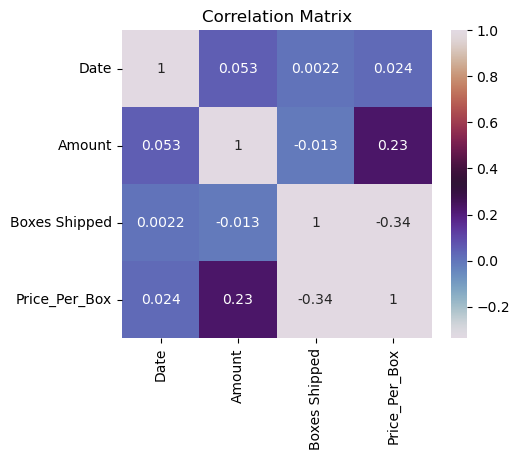

In [143]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, cmap = "twilight", annot = True)
plt.title('Correlation Matrix') # To create correlation heatmap

9.REGRESSION MODEL

In [134]:
trn = Sales.iloc[0:1000, ]
tst = Sales.iloc[1000:1338, ]
trn.to_csv('trn.csv')
trn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1000 non-null   object        
 1   Country        1000 non-null   object        
 2   Product_Name   1000 non-null   object        
 3   Date           1000 non-null   datetime64[ns]
 4   Amount         1000 non-null   int64         
 5   Boxes Shipped  1000 non-null   int64         
 6   Price_Per_Box  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 54.8+ KB


In [152]:
print("--- MODEL 1: Amount ~ Boxes Shipped ---")
model_1 = smf.ols(formula = 'Amount ~ Q("Boxes Shipped")', data = Sales).fit()
print(model_1.summary()) # To create Regression model 1

--- MODEL 1: Amount ~ Boxes Shipped ---
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.5677
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.451
Time:                        10:08:47   Log-Likelihood:                -32186.
No. Observations:                3282   AIC:                         6.438e+04
Df Residuals:                    3280   BIC:                         6.439e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [158]:
x_tst = tst.loc[:, tst.columns != 'Amount'] 
y_tst = tst.loc[:, tst.columns == 'Amount']
x_tst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 1000 to 1337
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   338 non-null    object        
 1   Country        338 non-null    object        
 2   Product_Name   338 non-null    object        
 3   Date           338 non-null    datetime64[ns]
 4   Boxes Shipped  338 non-null    int64         
 5   Price_Per_Box  338 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 16.0+ KB


In [159]:
y_tst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 1000 to 1337
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Amount  338 non-null    int64
dtypes: int64(1)
memory usage: 2.8 KB


Prediction Tests

In [160]:
pred_1 = model_1.predict(x_tst)
pred_1.head(10) # To show first ten rows 

1000    5983.720998
1001    6025.199791
1002    5942.708258
1003    6021.471361
1004    5912.414758
1005    6038.715353
1006    6033.122707
1007    6028.462168
1008    6024.733738
1009    6026.597953
dtype: float64

Residuals

In [163]:
resd_1=y_tst['Amount'] - pred_1
resd_1.head(10  # To show first ten rows 

1000     6497.279002
1001    -3918.199791
1002     2660.291742
1003     1461.528639
1004    -2531.414758
1005    -4008.715353
1006      525.877293
1007     4793.537832
1008    12672.266262
1009     -181.597953
dtype: float64

Plot of Actual vs Predicted

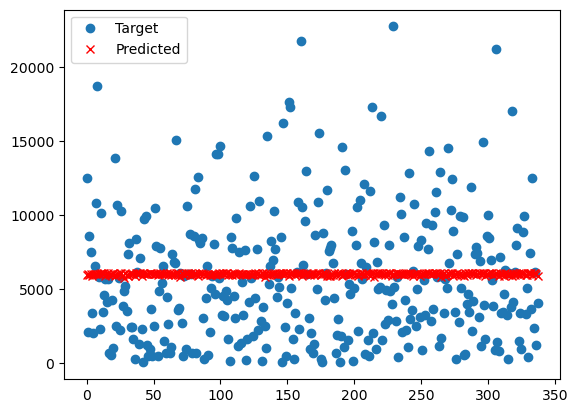

In [166]:
obsno = np.arange(0,338,1) 
fig, ax = plt.subplots() 
ax.plot(obsno, y_tst['Amount'], "o", label = "Target")
ax.plot(obsno, pred_1, "x", color = 'red', label = "Predicted")
ax.legend(loc = "best") 
plt.show() # To visually show target and predicted plot 

In [167]:
se_1 = resd_1.pow(2) 
sse_1 = se_1.sum()
msse_1 = sse_1/len(se_1)
rmse_1 = math.sqrt(msse_1) 
print(round(rmse_1, 2)) # RMSE Codes

4363.48


In [168]:
trn1 = trn.drop('Country', axis=1)
trn1.info() # To drop country

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1000 non-null   object        
 1   Product_Name   1000 non-null   object        
 2   Date           1000 non-null   datetime64[ns]
 3   Amount         1000 non-null   int64         
 4   Boxes Shipped  1000 non-null   int64         
 5   Price_Per_Box  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 47.0+ KB


In [169]:
trn1.head(10) # To show first 10 rows

,Sales Person,Product_Name,Date,Amount,Boxes Shipped,Price_Per_Box
0,Jehu Rudeforth,Mint Chip Choco,2022-01-04,5320,180,29.555556
1,Van Tuxwell,85% Dark Bars,2022-08-01,7896,94,84.000000
2,Gigi Bohling,Peanut Butter Cubes,2022-07-07,4501,91,49.461538
3,Jan Morforth,Peanut Butter Cubes,2022-04-27,12726,342,37.210526
4,Jehu Rudeforth,Peanut Butter Cubes,2022-02-24,13685,184,74.375000
5,Van Tuxwell,Smooth Sliky Salty,2022-06-06,5376,38,141.473684
6,Oby Sorrel,99% Dark & Pure,2022-01-25,13685,176,77.755682
7,Gunar Cockshoot,After Nines,2022-03-24,3080,73,42.191781
8,Jehu Rudeforth,50% Dark Bites,2022-04-20,3990,59,67.627119
9,Brien Boise,99% Dark & Pure,2022-07-04,2835,102,27.794118


In [171]:
trn1['Product_Name'] =trn1['Product_Name'].replace('Mint Chip Choco', 'Mint Chocolate')
trn1.head(10) # To replace product name

,Sales Person,Product_Name,Date,Amount,Boxes Shipped,Price_Per_Box
0,Jehu Rudeforth,Mint Chocolate,2022-01-04,5320,180,29.555556
1,Van Tuxwell,85% Dark Bars,2022-08-01,7896,94,84.000000
2,Gigi Bohling,Peanut Butter Cubes,2022-07-07,4501,91,49.461538
3,Jan Morforth,Peanut Butter Cubes,2022-04-27,12726,342,37.210526
4,Jehu Rudeforth,Peanut Butter Cubes,2022-02-24,13685,184,74.375000
5,Van Tuxwell,Smooth Sliky Salty,2022-06-06,5376,38,141.473684
6,Oby Sorrel,99% Dark & Pure,2022-01-25,13685,176,77.755682
7,Gunar Cockshoot,After Nines,2022-03-24,3080,73,42.191781
8,Jehu Rudeforth,50% Dark Bites,2022-04-20,3990,59,67.627119
9,Brien Boise,99% Dark & Pure,2022-07-04,2835,102,27.794118


In [153]:
print("\n--- MODEL 2 SUMMARY ---")
model_2 = smf.ols(formula = 'Amount ~ Q("Boxes Shipped") + Country', data = Sales).fit()
print(model_2.summary())  # To create Regression model 2


--- MODEL 2 SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8319
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.545
Time:                        10:09:02   Log-Likelihood:                -32183.
No. Observations:                3282   AIC:                         6.438e+04
Df Residuals:                    3275   BIC:                         6.442e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Int

In [156]:
print("\n--- MODEL 3 SUMMARY ---")
model_3 = smf.ols(formula = 'Amount ~ Q("Boxes Shipped") + Country + Product_Name', data = Sales).fit()
print(model_3.summary()) # To create Regression model 2


--- MODEL 3 SUMMARY ---
                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.748
Date:                Wed, 18 Feb 2026   Prob (F-statistic):            0.00980
Time:                        10:09:36   Log-Likelihood:                -32162.
No. Observations:                3282   AIC:                         6.438e+04
Df Residuals:                    3254   BIC:                         6.455e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [2]:
print("\n--- PLEASE REFER PART 2 ---")


--- PLEASE REFER PART 2 ---


In [1]:
print("\n--- THANK YOU ---")


--- THANK YOU ---
